In [1]:
# Install pandas into the current Python environment (run this cell once), then import it
import sys, subprocess
subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade", "pip"])
subprocess.check_call([sys.executable, "-m", "pip", "install", "pandas"])
import pandas as pd
subprocess.check_call([sys.executable, "-m", "pip", "install", "matplotlib", "datasets"])
import matplotlib.pyplot as plt
from datasets import load_dataset
import sys, subprocess
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset["train"].to_pandas()
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
from ast import literal_eval
df['job_skills']= df['job_skills'].apply(lambda x: literal_eval(x) if pd.notna(x) else x)


c:\Users\Admin\anaconda3\envs\python_data\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
df = df[df['job_title_short']== 'Data Analyst']

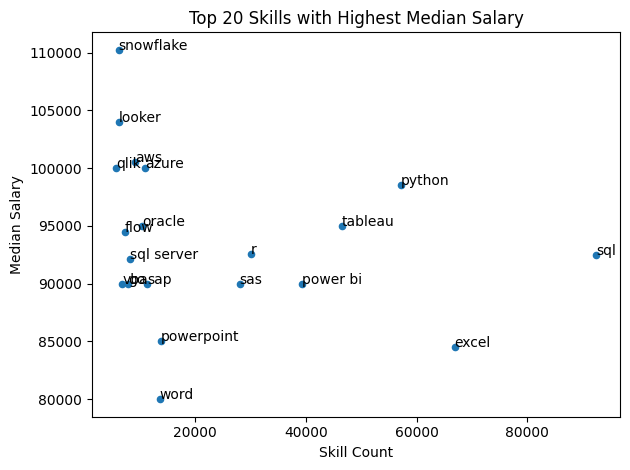

In [39]:
df_exploded = df.explode('job_skills')
skill_stats = df_exploded.groupby('job_skills').agg(
    skill_count=('job_skills','count'),
    median = ('salary_year_avg','median')
)

skill_stats = skill_stats.sort_values(by='skill_count', ascending =False).head(20)
#plot scatter plot
skill_stats.plot(kind='scatter', x='skill_count',y='median')
plt.xlabel('Skill Count')
plt.ylabel('Median Salary')
plt.title('Top 20 Skills with Highest Median Salary')
plt.tight_layout()

for i, txt in enumerate(skill_stats.index):
    plt.text(
        skill_stats['skill_count'].iloc[i],
        skill_stats['median'].iloc[i],
        txt,
    )



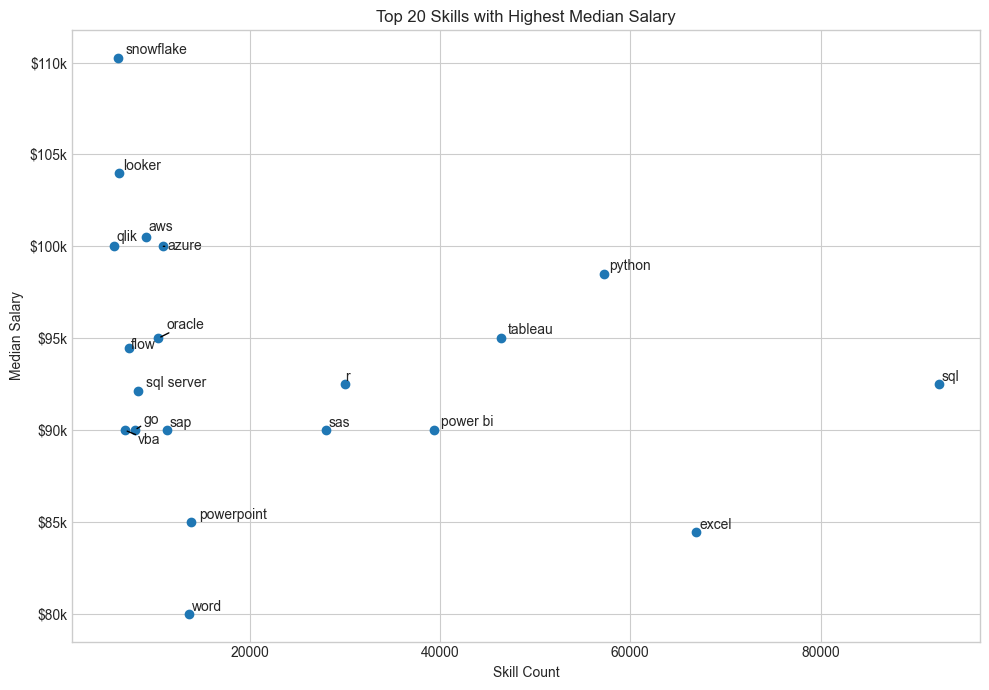

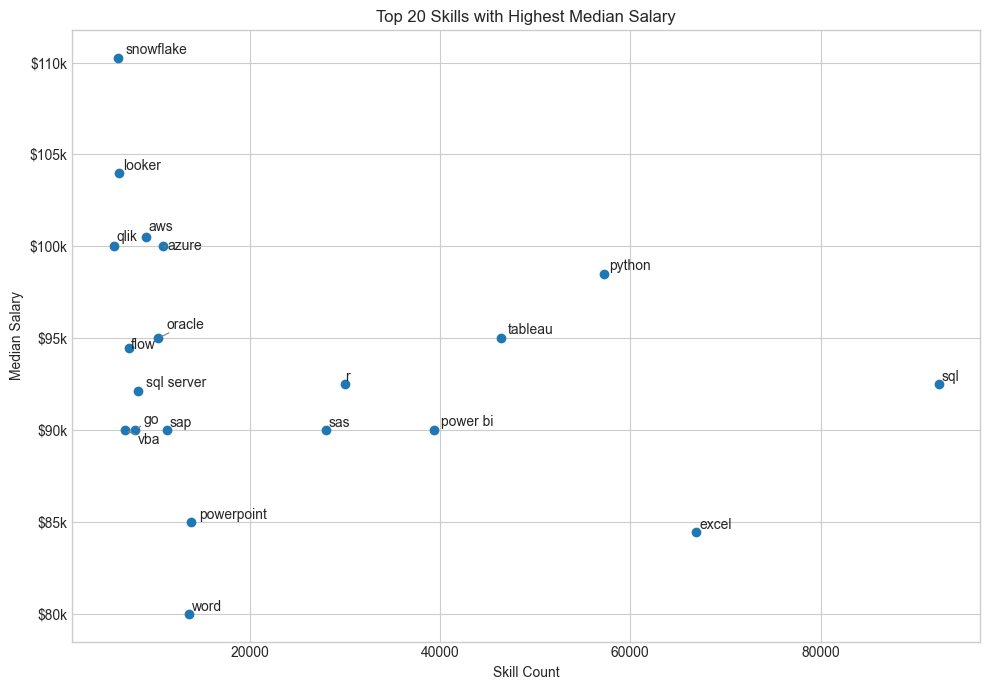

In [50]:
import matplotlib.ticker as mticker
from adjustText import adjust_text

fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(skill_stats['skill_count'], skill_stats['median'])

texts = []
for i, txt in enumerate(skill_stats.index):
    texts.append(
        ax.text(
            skill_stats['skill_count'].iloc[i],
            skill_stats['median'].iloc[i],
            txt,
            fontsize=10,
        )
    )

# Mũi tên nối label về đúng điểm khi bị dịch chỗ
adjust_text(
    texts,
    ax=ax,
    arrowprops=dict(arrowstyle='->', color='gray', lw=0.8),
)

# Format trục Y dạng $100k
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f'${x/1000:,.0f}k'))

ax.set_xlabel('Skill Count')
ax.set_ylabel('Median Salary')
ax.set_title('Top 20 Skills with Highest Median Salary')

plt.tight_layout()
plt.show()